# Multi-Subject Dictionary Learning (MSDL) and Functional Connectomes



---


**Machine Learning for Time Series (MVA 2025-2026)**  

**Student:** Corentin Caris
**Email:** corentin.caris@eleves.enpc.fr
\
**Student:** Yannaël Bossard
**Email:** yannael.bossard@ens-paris-saclay.fr  


**Project Deadline:** 04 / 01 / 2026



---


This notebook employs the MSDL algorithm (revisited version from Mensch et al. (2016)) to do video analysis.


---



## I- Video analysis: From fMRI to 2D video analysis
We aim to test the MSDL algorithm on video data. Mathematically, video analysis is structurally similar to fMRI analysis, as both involve decomposing high-dimensional spatiotemporal data:
- fMRI: 3D voxels changing over time.
- Video: 2D pixels changing over time.

Both can be described by the linear signal decomposition $Y \approx UV^T$, where $Y$ is the observed data, $U$ represents temporal loadings, and $V$ represents spatial maps.


In this study, we perform three experiments to test the capabilities and limits of MSDL:
Correlated Blinking Blobs: We generate videos of fixed blobs with

1.   correlated activation to validate the model in its intended "resting-state" scenario.
2.   Sequential Activation: We simulate "apparent motion" using fixed blobs to test if MSDL can recover temporal sequences despite lacking a causal model.
3.   Continuous Motion: We create a video of a single blob moving continuously in space to demonstrate the tracking limitation of dictionary learning and test its tiling capability.
4.   Real-World Application: Finally, we apply MSDL to the Background Models Challenge to extract frequent traffic pathways.



## II- Experiment 1: Fixed Blobs with Correlated Activation

We reproduce the synthetic experiment from Varoquaux et al. (2011) 4, but we introduce structured correlations to the time series $U$. In our modification, distinct blobs "pulse" together, simulating functional connectivity. We also apply a temporal smoothing filter to make the visualization interpretable for human observers.

**Results:** The model successfully extracted the blobs and reconstructed a denoised interpretable video.

## III- Video analysis and Shape extraction, Theoretical side

#### A/ Extract shapes in videos
Because MSDL is made for extracting dictionary/templates that are consistent across time and across subjects, **we wanted to use MSDL to extract shapes like cars in videos. However, MSDL is fundamentally designed for resting-state statistics (fixed networks that fluctuate), not for deterministic motion (objects continuously changing spatial coordinates).** The mismatch arises from three key assumptions in the paper:


1.   **Fixed Spatial Maps:** The model assumes that subject-specific maps are generated from a fixed population atlas. A moving object, however, changes its position at every frame. Since the model cannot "move" a map, it must treat every new position as a different component with high overlapping between frames, or as noise.
2.   **Gaussian Stationarity:** The paper explicitly states: "For resting-state brain activity, we do not model the loadings $U_s$ themselves, but their covariance"9. The prior $U^s \sim \mathcal{N}(0, \Sigma_U)$ assumes the signal oscillates around zero (stationarity). However, a moving object like a car is a non-stationary spike-ish in time for any given pixel, and it adds positive brightness (violating the fluctuacting zero-mean Gaussian assumptions).
3.   **Fundamental conflict:** The model interprets data as "same voxel + stochastic fluctuation". It lacks a concept of "same shape + deterministic translation", which would require a fixed-ish local-spatial template moving into global-space across time. Consequently, instead of learning that a blob is moving, it would see pixels that are noise level, and suddently activate once in the video, then goes back to noise level (except if the motion is highly periodic), so it would be penalized as noise.

In fact, the MSDL model reconstructs $Y^s \approx U^s V^s + E^s$ and $V^s = F^s + V$. The group atlas $V$ captures fixed-spatial patterns that are consistent across time and across subjects. Thus, even if objects are similar across subjects or time, $V$ won't captude the objects shapes, but will capture frequent pathsways/trajectories followed by the objects. In the real dataset used below, because cars always travel in lanes, but have different locations between frames/clipped videos, the groupp atlas $V$ will not look like individual cars but instead, it will look like probability heatmaps of the lanes/roads. This stands still when $S=1$, the MSDL becomes a Space PCA with $V^s \approx V$ and focus only across time, still extracting probability heatmaps.

**Conclusion:** MSDL does not suit for shape extraction or shape tracking in everyday life videos. However, it can still be very performant for extraction of probability heatmaps of frequently used trajectories.


#### B/ Enforce shapes extraction:

Despite these limitations, MSDL can track motion via the flip-book effect. If a car moves across 100 pixels, MSDL cannot represent this with a single car map. However, by giving enough components (model order $k$), it will learn a series of static images (frames) that, when activated sequentially, reconstruct the motion. However, this would highly not efficient compared to algorithm designed for moving shape , and it mades extracted dictionary/components poorly interpretable.


Another way to extract specific cars would be to segment one video into several shorter clips, treating it as a population of recordings. Therefore, the group atlas $V$ would capture patterns that are consistent across all subjects (e.g. roads), and subject variability $F^s  = V^s - V$ would represent the specific car in the clip of the subject $s$. However, that's a bit too much out of topic for that project.

## IV- Experiment 2: Application to synthetic videos

#### A/ Sequential Activation (Apparent Motion)
We created videos where fixed, aligned blobs activate in sequence ($A \to B \to C$).

**Results:**  MSDL correctly learns the positions of the blobs and reproduces their temporal activation sequence in $U$. This confirms that while MSDL cannot model causality (it doesn't know $A$ causes $B$), it successfully captures the temporal structure of sequentially active regions. When increasing the order of the model, it tended to tile each frames, as the flipping book analogy.

#### B/ Continuous Motion
We generated a video of a single blob moving continuously through space.

**Methods:**
This setup does NOT align with the MSDL generative model, which assumes:
- Fixed Spatial Maps ($V$): The blobs do not move.
- Stochastic Time Courses ($U$): Modeled by a covariance matrix $\Sigma_U$.
- Spatial Sparsity: The signal is spatially localized against a noisy background.

Because this breaks the MSDL assumption of fixed maps ($Y \approx UV^T$), we could not use matrix multiplication. We generated the video frame-by-frame, calculating the exact spatial position of the blob at every step.

**Results:** We confirmed the flip-book limitation. Low order modeled did not succeeded in extracting the single blob shape ofo the video. And efficient recovery of the video was only possible when the number of components approached the number of unique spatial positions, but it mades components interpretation difficult.

## V- Application to real data

We applied MSDL to 1-minute videos of moving cars from the `Background Models Challenge` dataset. We took the file "121.mp4" from backgroundmodelschallenge.eu. This consists in a street view simulation with a roundabout where nothing is moving expect cars coming from the background, and going either frontway or left at the roundabout.

As explained above, since the maps $V$ are fixed, the algorithm does not learn that cars are moving. Instead, it learns places/trajectories where cars usually are. By aggregating the signal over time, MSDL extracts the functional regions of the video, e.g. the roads and traffic lanes, while filtering out transient noise.

**Results:**
While MSDL is poorly suited for tracking individual cars due to the limitations described above, it proved highly effective for atlas extraction. It successfully extracted 2 components corresponding to the 2 pathways used by the cars.



---







\
**References:**\
Studied paper: https://inria.hal.science/inria-00588898v1/document \
External Resource: https://nilearn.github.io/stable/index.html# \
Dataset: https://backgroundmodelschallenge.eu/

In [1]:
# Packages

try:
  from nilearn import datasets
except:
  !pip install nilearn

import numpy as np
import matplotlib.pyplot as plt
import math
import nibabel as nib
from nilearn.decomposition import DictLearning

from scipy.ndimage import gaussian_filter
import matplotlib.animation as animation
from IPython.display import HTML  # for notebook animation display




## Tools

In [2]:

def preprocessing_video(video_data):
  '''
  Hand-made video input need to be preprocessed before fit with MSDL
  '''

  video_data = video_data.astype(np.float64)

  # center the video
  h, w = video_data.shape[1], video_data.shape[2]
  video_data -= video_data.mean(axis=0, keepdims=True)

  # Prepare for Nilearn by wrapping as NIfTI (Height, Width, Depth=1, Time)
  video_4d = video_data.transpose(1, 2, 0)[:, :, np.newaxis, :]
  affine = np.eye(4)
  video_nifti = nib.Nifti1Image(video_4d, affine)

  # Create a mask to consider the whole video (and prevent cropping because of brain images expectation)
  mask_data = np.ones((h, w, 1), dtype=np.int8)
  mask_img = nib.Nifti1Image(mask_data, affine)

  return video_nifti, mask_img

def MSDL_component_extraction(video_nifti, mask_img, n_components=5, alpha=0.5):
  '''
  1/ fit the MSDL model
  2/ Extract the time series (U)
  3/ Extract the spatial maps (V)
  4/ Mathematical Reconstruction: Y_approx = U*V^T
  '''

  n_frames, h, w = video_data.shape[0], video_data.shape[1], video_data.shape[2]

  # Create the MSDL using Nilearn function
  msdl = DictLearning(
      n_components=n_components,
      alpha=alpha,
      memory=None,
      verbose=0,
      random_state=0,
      n_epochs=25,
      mask=mask_img,
      standardize=False,
      n_jobs=1,
  )
  # fit MSDL to input data
  msdl.fit(video_nifti)

  # Extract time series (U)
  time_series_list = msdl.transform(video_nifti) # (n_subjects,)
  time_series = time_series_list[0]  # (n_frames, n_components)


  # Extract the spatial maps (V)
  maps_img = msdl.components_img_
  maps_data = maps_img.get_fdata() # (Height, Width, Depth=1, n_components)
  maps_flat = maps_data.squeeze().reshape(-1, msdl.n_components) # (n_pixels, n_components)

  # Mathematical Reconstruction: Y_approx = U*V^T
  reconstructed_flat = time_series @ maps_flat.T
  reconstructed_video = reconstructed_flat.reshape(n_frames, h, w) # (n_frames, h, w)

  return time_series, maps_data, reconstructed_video




### Displaying tools

In [3]:
def plot_spatial_maps_per_compo(maps_data):
  '''
  Plot the spatial maps (V) for each component.
  '''
  n_components = maps_data.shape[-1]

  ### Plot
  n_cols = 5
  n_rows = math.ceil(n_components / n_cols)
  plt.figure(figsize=(3 * n_cols, 3 * n_rows))
  plt.suptitle(f"Visualization the {n_components} Spatial Dictionary Maps (V)", fontsize=14, y=1.02)

  for i in range(n_components):

    ax = plt.subplot(n_rows, n_cols, i + 1)

    # Extract the i-th map
    map_img = maps_data[:, :, 0, i]

    # Plot
    vmax = np.max(np.abs(map_img)) # Scale colormap to max value
    im = ax.imshow(map_img, cmap='bwr', vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.set_title(f"Map #{i+1}", fontsize=10)
    ax.axis('off')
  plt.tight_layout()
  plt.show()


def plot_activation(video_data, reconstructed_video, time_series, frame_idx=13):
  '''
  Plot 1 frame of the original video and the reconstructed video

  Plot the temporal activation of the main component
  '''

  plt.figure(figsize=(15, 5))
  plt.suptitle(f"MSDL Analysis at Frame {frame_idx}", fontsize=16)

  # Original
  plt.subplot(1, 3, 1)
  plt.imshow(video_data[frame_idx], cmap='gray')
  plt.title("Original Frame")
  plt.axis('off')

  # Reconstructed
  plt.subplot(1, 3, 2)
  plt.imshow(reconstructed_video[frame_idx], cmap='gray')
  plt.title("Reconstructed (U*V^T)")
  plt.axis('off')

  # Main component map at specific frame
  dominant_comp_idx = np.argmax(np.abs(time_series[frame_idx]))
  dominant_map = maps_data[:, :, 0, dominant_comp_idx]
  plt.subplot(1, 3, 3)
  plt.imshow(dominant_map, cmap='hot')
  plt.title(f"Most Active Dictionary Map #{dominant_comp_idx}")
  plt.axis('off')
  plt.show()

  # Time Series Plot: should show when the specific map turned on and turned off-ish
  plt.figure(figsize=(12, 4))
  plt.plot(time_series[:, dominant_comp_idx], linewidth=2, color='red')
  plt.title(f"Temporal Activation of Map #{dominant_comp_idx}")
  plt.xlabel("Time (Frames)")
  plt.ylabel("Activation Strength")
  plt.grid(True)
  plt.show()


def display_video_origin_reconstr(original_video, reconstructed_video, interval=100):
  '''
  Creates an animation comparing Original vs Reconstructed video.
  '''

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
  plt.close()

  # Initialize the images (using the first frame)
  im1 = ax1.imshow(original_video[0], cmap='gray', vmin=-0.5, vmax=1.5, animated=True)
  ax1.set_title("Original")
  ax1.axis('off')

  im2 = ax2.imshow(reconstructed_video[0], cmap='gray', vmin=-0.5, vmax=1.5, animated=True)
  ax2.set_title("MSDL Reconstruction")
  ax2.axis('off')

  # Define the update function for the animation loop
  def update(frame_idx):
      im1.set_array(original_video[frame_idx])
      im2.set_array(reconstructed_video[frame_idx])
      return im1, im2

  # Create the animation object
  ani = animation.FuncAnimation(fig, update, frames=len(original_video), interval=interval, blit=True) # interval in ms
  # ani.save("denoised_traffic.gif", writer="pillow", fps=15)

  return ani


## II- Experiment 1: Fixed Blobs with Correlated Activation

We reproduce the synthetic experiment from Varoquaux et al. (2011) 4, but we introduce structured correlations to the time series $U$. In our modification, distinct blobs "pulse" together, simulating functional connectivity. We also apply a temporal smoothing filter to make the visualization interpretable for human observers.

**Results:** The model successfully extracted the blobs and reconstructed a denoised interpretable video.

In [4]:


def generate_correlated_blobs(n_frames=100, width=50, height=50, n_maps=5):
  '''
  Generates synthetic data compatible with Varoquaux et al. (2011),
  but adds structured correlations to U (time series) such that some blobs pulse together.
  '''

  # Define the grid
  x = np.arange(width)
  y = np.arange(height)
  X, Y = np.meshgrid(x, y)

  # Initialize Spatial Maps (V)
  n_pixels = width*height
  V = np.zeros((n_pixels, n_maps))
  occupied_mask = np.zeros((height, width), dtype=bool)

  # Spatial generation (V)
  for k in range(n_maps):
    n_blobs = max(1, np.random.binomial(n=3, p=0.5)) # Number of blobs: Binomial(n=3, p=0.5)
    map_2d = np.zeros((height, width))

    for _ in range(n_blobs):
      for attempt in range(123):
        cx = np.random.randint(0, width)
        cy = np.random.randint(0, height)
        sigma = np.random.uniform(2, 4)

        dist_sq = (X - cx)**2 + (Y - cy)**2
        blob = np.exp(-dist_sq / (2 * sigma**2))
        blob_mask = blob > 0.25 # less than 25% overlapping

        # Check overlap
        if not np.any(occupied_mask & blob_mask):
          map_2d += blob
          occupied_mask = occupied_mask | blob_mask
          break

    V[:, k] = map_2d.flatten()

  # Temporal generation (U) (with correlation)
  cov_matrix = np.eye(n_maps) # indepedndent Covariance Matrix (Sigma_U)

  # Add strong symmetric correlations between selected maps to get simultaneous pulse (like a network)
  correlation_strength=0.8
  if n_maps >= 2:
    cov_matrix[0, 1] = correlation_strength
    cov_matrix[1, 0] = correlation_strength
  if n_maps >= 4:
      cov_matrix[2, 3] = -correlation_strength
      cov_matrix[3, 2] = -correlation_strength
  if n_maps <= 1:
    print(" No correlation possible ... You should take at least 2 maps !")


  # Generate Time Series
  mean_vec = np.zeros(n_maps)
  U = np.random.multivariate_normal(mean_vec, cov_matrix, size=n_frames)

  # Temporal Smoothing for Visualization, otherwise we can't see blinkings
  U = gaussian_filter(U, sigma=(2.0, 0))
  U = U / np.std(U, axis=0) # Re-normalize

  # Construction of the "blinking blobs" video => Y=U*V.T
  Y_flat = np.dot(U, V.T)
  video_data = Y_flat.reshape(n_frames, height, width)
  # Add Noise
  noise = np.random.normal(0, 0.5, size=video_data.shape)
  correlated_noise = gaussian_filter(noise, sigma=(0, 1.0, 1.0))

  return video_data + correlated_noise, V, U



In [15]:
# Generate the video
n_frames, h, w = 100, 50, 50
video_data, ground_truth_V, ground_truth_U = generate_correlated_blobs(n_frames, w, h)

# process the video with the MSDL algo
video_nifti, mask_img = preprocessing_video(video_data)
time_series, maps_data, reconstructed_video = MSDL_component_extraction(video_nifti, mask_img, n_components=5, alpha=0.5)

# Visualization
plot_spatial_maps_per_compo(maps_data)

plot_activation(video_data, reconstructed_video, time_series, frame_idx=13)

anim = display_video_origin_reconstr(video_data, reconstructed_video,interval=100)

'''
# Saving
if False:
  output_filename = "msdl_reconstruction1.gif"
  print(f"Saving {output_filename}...")
  anim.save(output_filename, writer="pillow", fps=10)

  # 2. Download the file to your computer (if using Colab)
  from google.colab import files
  files.download(output_filename)
'''

HTML(anim.to_jshtml())



Output hidden; open in https://colab.research.google.com to view.




## III- Video tracking: Sequential and Continuous Motion

#### A/ Extract shapes in videos
Because MSDL is made for extracting dictionary/templates that are consistent across time and across subjects, **we wanted to use MSDL to extract shapes like cars in videos. However, MSDL is fundamentally designed for resting-state statistics (fixed networks that fluctuate), not for deterministic motion (objects continuously changing spatial coordinates).** The mismatch arises from three key assumptions in the paper:


1.   **Fixed Spatial Maps:** The model assumes that subject-specific maps are generated from a fixed population atlas. A moving object, however, changes its position at every frame. Since the model cannot "move" a map, it must treat every new position as a different component with high overlapping between frames, or as noise.
2.   **Gaussian Stationarity:** The paper explicitly states: "For resting-state brain activity, we do not model the loadings $U_s$ themselves, but their covariance"9. The prior $U^s \sim \mathcal{N}(0, \Sigma_U)$ assumes the signal oscillates around zero (stationarity). However, a moving object like a car is a non-stationary spike-ish in time for any given pixel, and it adds positive brightness (violating the fluctuacting zero-mean Gaussian assumptions).
3.   **Fundamental conflict:** The model interprets data as "same voxel + stochastic fluctuation". It lacks a concept of "same shape + deterministic translation", which would require a fixed-ish local-spatial template moving into global-space across time. Consequently, instead of learning that a blob is moving, it would see pixels that are noise level, and suddently activate once in the video, then goes back to noise level (except if the motion is highly periodic), so it would be penalized as noise.

In fact, the MSDL model reconstructs $Y^s \approx U^s V^s + E^s$ and $V^s = F^s + V$. The group atlas $V$ captures fixed-spatial patterns that are consistent across time and across subjects. Thus, even if objects are similar across subjects or time, $V$ won't captude the objects shapes, but will capture frequent pathsways/trajectories followed by the objects. In the real dataset used below, because cars always travel in lanes, but have different locations between frames/clipped videos, the groupp atlas $V$ will not look like individual cars but instead, it will look like probability heatmaps of the lanes/roads. This stands still when $S=1$, the MSDL becomes a Space PCA with $V^s \approx V$ and focus only across time, still extracting probability heatmaps.

**Conclusion:** MSDL does not suit for shape extraction in everyday life videos.


#### B/ Enforce shapes extraction:

Despite these limitations, MSDL can track motion via the flip-book effect. If a car moves across 100 pixels, MSDL cannot represent this with a single car map. However, by giving enough components (model order $k$), it will learn a series of static images (frames) that, when activated sequentially, reconstruct the motion. However, this would highly not efficient compared to algorithm designed for moving shape , and it mades extracted dictionary/components poorly interpretable.


Another way to extract specific cars would be to segment one video into several shorter clips, treating it as a population of recordings. Therefore, the group atlas $V$ would capture patterns that are consistent across all subjects (e.g. roads), and subject variability $F^s  = V^s - V$ would represent the specific car in the clip of the subject $s$. However, that's a bit too much out of topic for that project.


#### A/ Sequential Activation (Apparent Motion)
We created videos where fixed, aligned blobs activate in sequence ($A \to B \to C$).

**Results:**  MSDL correctly learns the positions of the blobs and reproduces their temporal activation sequence in $U$. This confirms that while MSDL cannot model causality (it doesn't know $A$ causes $B$), it successfully captures the temporal structure of sequentially active regions. When increasing the order of the model, it tended to tile each frames, as the flipping book analogy.

#### B/ Continuous Motion
We generated a video of a single blob moving continuously through space.

**Methods:**
This setup does NOT align with the MSDL generative model, which assumes:
- Fixed Spatial Maps ($V$): The blobs do not move.
- Stochastic Time Courses ($U$): Modeled by a covariance matrix $\Sigma_U$.
- Spatial Sparsity: The signal is spatially localized against a noisy background.

Because this breaks the MSDL assumption of fixed maps ($Y \approx UV^T$), we could not use matrix multiplication. We generated the video frame-by-frame, calculating the exact spatial position of the blob at every step.

**Results:** We confirmed the flip-book limitation. Low order modeled did not succeeded in extracting the single blob shape ofo the video. And efficient recovery of the video was only possible when the number of components approached the number of unique spatial positions, but it mades components interpretation difficult.






### Fake tracking
(it's actually several fixed blobs that activates sequencely)

In [6]:


def generate_traveling_blobs(n_frames=100, width=50, height=50, n_blobs=5, backandforth=1):
  '''
  Generates a 'traveling blob' where 5 aligned blobs activate sequentially.
  Sequence: A -> B -> C -> D -> E -> D -> C -> B -> A.
  '''

  # Create grid
  x = np.arange(width)
  y = np.arange(height)
  X, Y = np.meshgrid(x, y)

  # Initialize Spatial Maps (V)
  n_pixels = width * height
  V = np.zeros((n_pixels, n_blobs))

  centers_x = np.linspace(10, width - 10, n_blobs) # Aligned and evenly space along horizontal
  center_y = height // 2
  for k in range(n_blobs):
    sigma = 3.0
    dist_sq = (X - centers_x[k])**2 + (Y - center_y)**2
    blob = np.exp(-dist_sq / (2 * sigma**2)) # Gaussian blob
    V[:, k] = blob.flatten()

  # Initialize Time Series (U)
  U = np.zeros((n_frames, n_blobs))

  period = n_frames //(2*backandforth) # Speed of the wave
  for t in range(n_frames):
    cycle_pos = (t % (2 * period)) / period
    if cycle_pos > 1:
        target_idx = n_blobs - 1 - (cycle_pos - 1) * (n_blobs - 1) # Going backward
    else:
        target_idx = cycle_pos * (n_blobs - 1) # Going forward

    for k in range(n_blobs):
      dist = abs(k - target_idx)
      activation = np.exp(-dist**2 / (0.5**2)) # Gaussian temporal activation (only active if wave is near)
      U[t, k] = activation

  # Construction of the video => Y=U*V.T
  Y_flat = np.dot(U, V.T)
  video_data = Y_flat.reshape(n_frames, height, width)
  # Add noise
  noise = np.random.normal(0, 0.1, size=video_data.shape)

  return video_data + noise, V, U


In [14]:
# Generate the video
n_frames, h, w = 100, 50, 50
video_data, ground_truth_V, ground_truth_U = generate_traveling_blobs(n_frames, w, h, n_blobs=5, backandforth=5)

# process the video with the MSDL algo
video_nifti, mask_img = preprocessing_video(video_data)
time_series, maps_data, reconstructed_video = MSDL_component_extraction(video_nifti, mask_img, n_components=5, alpha=0.5)

# Visualization
plot_spatial_maps_per_compo(maps_data)

plot_activation(video_data, reconstructed_video, time_series, frame_idx=13)

anim = display_video_origin_reconstr(video_data, reconstructed_video,interval=50)

'''
# Saving
if False:
  output_filename = "msdl_reconstruction2.gif"
  print(f"Saving {output_filename}...")
  anim.save(output_filename, writer="pillow", fps=10)

  # 2. Download the file to your computer (if using Colab)
  from google.colab import files
  files.download(output_filename)
'''

HTML(anim.to_jshtml())



Output hidden; open in https://colab.research.google.com to view.

### Real tracking
(it's actually 1 blob moving into space)

In [8]:


def generate_moving_blob(n_frames=100, width=50, height=50, mode='spiral'):
    '''
    Generates a single Gaussian blob that moves continuously (breaking MSDL fixed-map assumption).

    Parameters:
    - mode: ['spiral', 'random'] (respectively deterministic and stochastic random walk)
    '''

    video_data = np.zeros((n_frames, height, width))

    # Create coordinate grid
    x = np.arange(width)
    y = np.arange(height)
    X, Y = np.meshgrid(x, y)

    # Compute Trajectory
    trajectory = np.zeros((n_frames, 2)) # [x, y]
    cx, cy = width // 2, height // 2 # Starting center
    velocity_x, velocity_y = 0, 0

    for t in range(n_frames):
      if mode == 'spiral':
        # Polar coordinates
        angular_speed = 0.2
        radial_expansion = 0.15
        theta = t * angular_speed
        r = t * radial_expansion

        # Convert to Cartesian relative to center
        cx = (width // 2) + r * np.cos(theta)
        cy = (height // 2) + r * np.sin(theta)

      elif mode == 'random':
        # Smooth Random Walk (simulate inertia)
        velocity_x += np.random.normal(0, 0.5)
        velocity_y += np.random.normal(0, 0.5)
        velocity_x *= 0.9  # Dampen velocity
        velocity_y *= 0.9

        # Update position
        cx += velocity_x
        cy += velocity_y

        # Bounce off walls
        if cx < 2 or cx > width - 2: velocity_x *= -1
        if cy < 2 or cy > height - 2: velocity_y *= -1
        cx = np.clip(cx, 0, width-1)
        cy = np.clip(cy, 0, height-1)

      trajectory[t] = [cx, cy]

      # Render Gaussian Blob at this exact position
      sigma = 3.0
      dist_sq = (X - cx)**2 + (Y - cy)**2
      blob = np.exp(-dist_sq / (2 * sigma**2))
      video_data[t] = blob

    # Add noise
    noise = np.random.normal(0, 0.1, size=video_data.shape)
    return video_data + noise, trajectory


In [13]:


# Generate the video
n_frames, h, w = 100, 50, 50
video_data, trajectory = generate_moving_blob(n_frames=n_frames, width=w, height=h, mode="random")

# process the video with the MSDL algo
video_nifti, mask_img = preprocessing_video(video_data)
time_series, maps_data, reconstructed_video = MSDL_component_extraction(video_nifti, mask_img, n_components=30, alpha=0.5)

# Visualization
plot_spatial_maps_per_compo(maps_data)

plot_activation(video_data, reconstructed_video, time_series, frame_idx=13)

anim = display_video_origin_reconstr(video_data, reconstructed_video,interval=50)

'''
# Saving
if False:
  output_filename = "msdl_reconstruction3.gif"
  print(f"Saving {output_filename}...")
  anim.save(output_filename, writer="pillow", fps=10)

  # 2. Download the file to your computer (if using Colab)
  from google.colab import files
  files.download(output_filename)
'''

HTML(anim.to_jshtml())



Output hidden; open in https://colab.research.google.com to view.

## IV- Application to real data

We applied MSDL to 1-minute videos of moving cars from the Background Models Challenge dataset. We took the file "121.mp4" from backgroundmodelschallenge.eu. This consists in a street view simulation with a roundabout where nothing is moving expect cars coming from the background, and going either frontway of left at the roundabout.

As explained above, since the maps $V$ are fixed, the algorithm does not learn that cars are moving. Instead, it learns places/trajectories where cars usually are. By aggregating the signal over time, MSDL extracts the functional regions of the video, e.g. the roads and traffic lanes, while filtering out transient noise.

**Results:**
While MSDL is poorly suited for tracking individual cars due to the limitations described above, it proved highly effective for atlas extraction. It successfully extracted 2 components corresponding to the 2 pathways used by the cars.



In [10]:
import cv2
from google.colab import drive

drive.mount('/content/drive')
video_path = '/content/drive/MyDrive/Colab Notebooks/synth1/121.mp4'

cap = cv2.VideoCapture(video_path)
frames = []
frame_count = 0

# Read & Reduce the video
while True:
    ret, frame = cap.read()
    if not ret or len(frames) >= 1000:
        break

    #  Skip frames
    frame_count += 1
    if frame_count % 2 != 0:
        continue

    # Convert to Grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Resize
    resize_factor = 0.5
    if resize_factor != 1.0:
        h, w = gray.shape
        new_dim = (int(w * resize_factor), int(h * resize_factor))
        gray = cv2.resize(gray, new_dim, interpolation=cv2.INTER_AREA)

    frames.append(gray)
cap.release()

video_data = np.array(frames)
print(video_data.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(749, 240, 320)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(


[DictLearning.wrapped] Resampling images

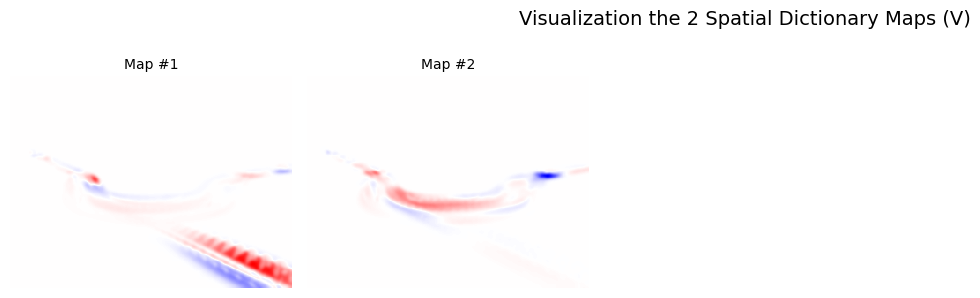

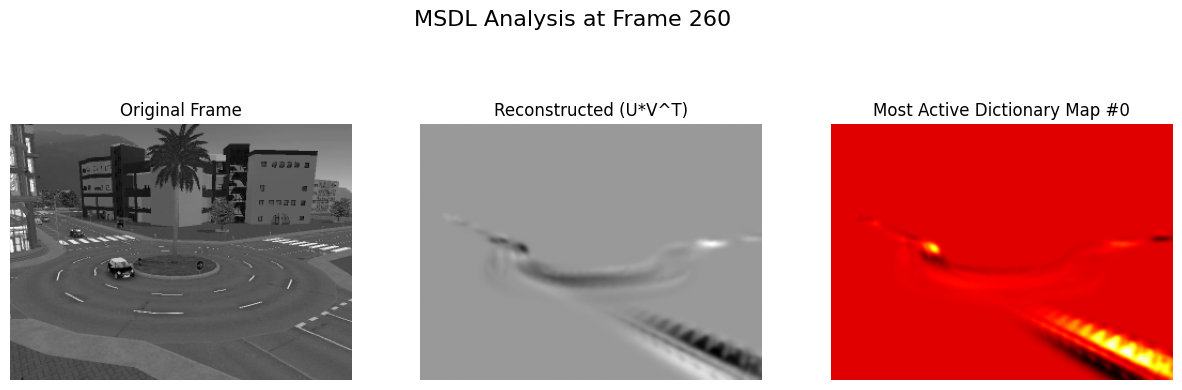

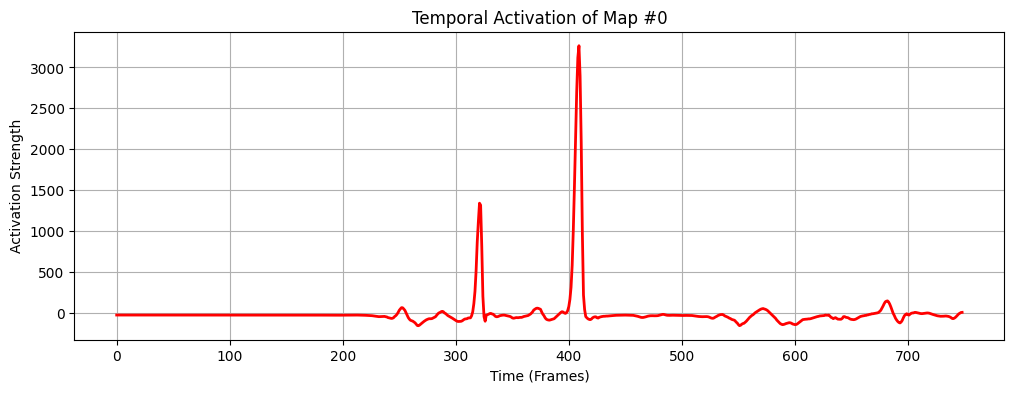

In [11]:

# process the video with the MSDL algo
video_nifti, mask_img = preprocessing_video(video_data)
time_series, maps_data, reconstructed_video = MSDL_component_extraction(video_nifti, mask_img, n_components=2, alpha=0.5)

# Visualization
plot_spatial_maps_per_compo(maps_data)

plot_activation(video_data, reconstructed_video, time_series, frame_idx=260)


In [12]:
# process the video with the MSDL algo
video_nifti, mask_img = preprocessing_video(video_data)
time_series, maps_data, reconstructed_video = MSDL_component_extraction(video_nifti, mask_img, n_components=50, alpha=0.5)

# Visualization
plot_spatial_maps_per_compo(maps_data)

plot_activation(video_data, reconstructed_video, time_series, frame_idx=13)

anim = display_video_origin_reconstr(video_data, reconstructed_video,interval=50)
plt.rcParams['animation.embed_limit'] = 100
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.